In [2]:
from google.colab import drive
import os
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/AM


In [6]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [7]:
G = nx.DiGraph()
G.add_nodes_from(visited)
G.add_edges_from(sample_edges)

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 2266


In [8]:
G_undirected = G.to_undirected()
components = list(nx.connected_components(G_undirected))
print(f"Number of connected components (undirected): {len(components)}")
gcc = max(components, key=len)
print(f"Size of GCC (undirected): {len(gcc)}")

Number of connected components (undirected): 1
Size of GCC (undirected): 300


Fully connected graph sampled from whole graph due to size.

Nodes: 300, Vertices: 1744


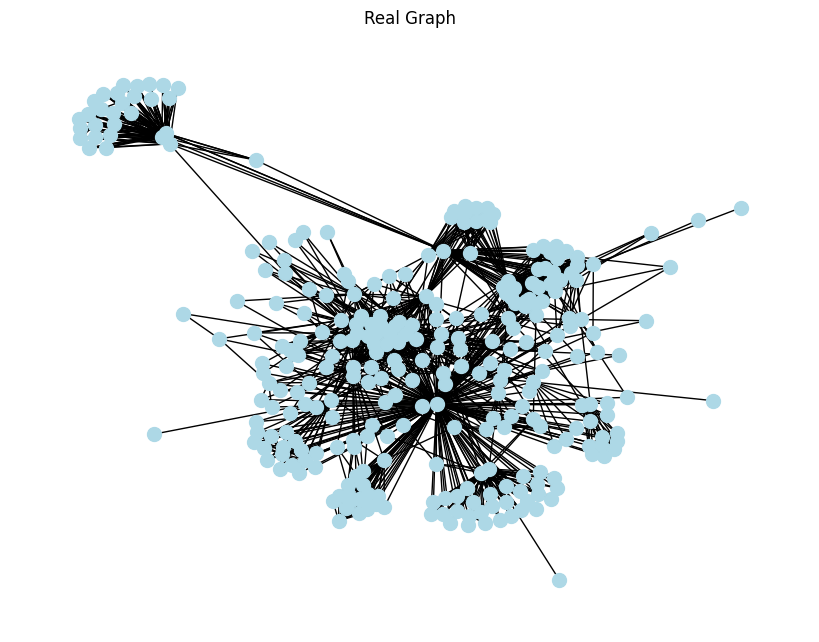

In [10]:
G_directed = nx.DiGraph()
G_directed.add_nodes_from(visited)
G_directed.add_edges_from(sample_edges)
G = G_directed.to_undirected()

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=100, node_color='lightblue', with_labels=False)
plt.title("Real Graph")
plt.show()

In [13]:
avg_shortest_path_length = nx.average_shortest_path_length(G_undirected)
avg_clustering_coefficient = nx.average_clustering(G_undirected)

print("Real Graph:")
print(f"Average Shortest Path Length: {avg_shortest_path_length:.2f}")
print(f"Average Clustering Coefficient: {avg_clustering_coefficient:.2f}")

Real Graph:
Average Shortest Path Length: 2.57
Average Clustering Coefficient: 0.78


Erdős-Rényi Graph - Nodes: 300, Edges: 1744


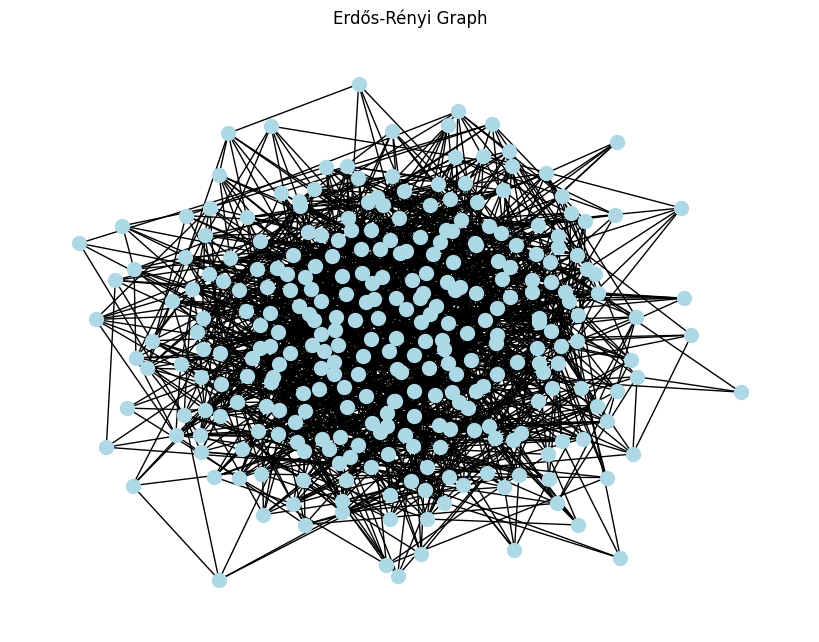

In [12]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

G_ER = nx.gnm_random_graph(n_nodes, n_edges)

print(f"Erdős-Rényi Graph - Nodes: {nx.number_of_nodes(G_ER)}, Edges: {nx.number_of_edges(G_ER)}")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_ER, seed=42)
nx.draw(G_ER, pos, node_size=100, node_color='lightblue', with_labels=False)
plt.title(f"Erdős-Rényi Graph")
plt.show()

In [14]:
avg_shortest_path_length = nx.average_shortest_path_length(G_ER)
avg_clustering_coefficient = nx.average_clustering(G_ER)

print("Erdős-Rényi Graph:")
print(f"Average Shortest Path Length: {avg_shortest_path_length:.2f}")
print(f"Average Clustering Coefficient: {avg_clustering_coefficient:.2f}")

Erdős-Rényi Graph:
Average Shortest Path Length: 2.59
Average Clustering Coefficient: 0.04


While the shortest path length of both graphs is relatively similar, the clustering is much more prominent on the real graph.

The real graph could be classified as a small world network. Although bias is possible due to the sampling method, it is nonetheless fitting for a Google web graph to be a small world network due to the sheer connectedness through hyperlinks.

In [15]:
node_betweenness = nx.betweenness_centrality(G)
edge_betweenness = nx.edge_betweenness_centrality(G)

# Identify top nodes acting as shortcuts
sorted_nodes = sorted(node_betweenness.items(), key=lambda item: item[1], reverse=True)
print("Nodes acting as shortcuts (top 2 by betweenness centrality):")
for node, centrality in sorted_nodes[:2]:
  print(f"Node {node}: {centrality:.4f}")

# Identify top edges acting as shortcuts
sorted_edges = sorted(edge_betweenness.items(), key=lambda item: item[1], reverse=True)
print("\nEdges acting as shortcuts (top 2 by betweenness centrality):")
for edge, centrality in sorted_edges[:2]:
  print(f"Edge {edge}: {centrality:.4f}")

Nodes acting as shortcuts (top 2 by betweenness centrality):
Node 908351: 0.6696
Node 121288: 0.1649

Edges acting as shortcuts (top 2 by betweenness centrality):
Edge (908351, 121288): 0.0915
Edge (585438, 121288): 0.0371
